# Clacular factores de horas pico durante los periodos de viaje

In [7]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


In [8]:
PATH = r"C:\proyectos\red-vial-guadalajara\OneDrive_2026-08-25"
FOLDER_MATRIZ = r"Insumos IMEPLAN\Matriz Origen Destino"
FOLDER_ZONAS = r"red_shapefiles\zones_agebs_visum"

In [9]:
matriz_global = pd.read_excel(os.path.join(PATH, FOLDER_MATRIZ, "matriz_origen_destino_agebs_por_hora_por_modo.xlsx"))
matriz_global.head()

,¿A qué hora comenzó su viaje? | Hora de inicio | Horas,Grupo modal del viaje,Tipo de transporte,Origen,Destino,Sum of Ponderador
0,0,1.- A pie,Transporte No Motorizado,140440011,140440011,182
1,0,1.- A pie,Transporte No Motorizado,140440026,140440026,30
2,0,1.- A pie,Transporte No Motorizado,140510016,140510016,118
3,0,1.- A pie,Transporte No Motorizado,140970123,140970123,70
4,0,1.- A pie,Transporte No Motorizado,140973679,140973679,10


In [10]:
matriz_global['Tipo de transporte'].unique()

<ArrowStringArray>
['Transporte No Motorizado', 'Transporte Privado', 'Transporte Público']
Length: 3, dtype: str

In [11]:
matriz_global_priv = matriz_global[matriz_global['Tipo de transporte'] == 'Transporte Privado']

In [12]:
matriz_global_priv.shape

(39097, 6)

In [13]:
matriz_global_priv.columns.tolist()

['¿A qué hora comenzó su viaje? | Hora de inicio | Horas',
 'Grupo modal del viaje',
 'Tipo de transporte',
 'Origen',
 'Destino',
 'Sum of Ponderador']

Verificamos que sea la base de datos correcta, que contenga más de 11 millones de viajes (suma de los valores de la columna Sum of Ponderador)

In [14]:
print('Número de viajes: ', matriz_global_priv['Sum of Ponderador'].sum())

Número de viajes:  3937278


Se tienen más de 11 millones de registros, continuamos con el pipeline.

Renombraré las variables para mayor practicidad. En caso de que sí requieran esos nombres en específico simplemente se omite la siguiente celda y se cambia la manera en la que se llaman las variables con pandas.

In [15]:
matriz_global_priv = matriz_global_priv.rename(columns = {'¿A qué hora comenzó su viaje? | Hora de inicio | Horas' : 'Hora_inicio'})

In [16]:
matriz_global_priv = matriz_global_priv.rename(columns = {'Sum of Ponderador' : 'Ponderador'})

In [17]:
matriz_global_priv.head()

,Hora_inicio,Grupo modal del viaje,Tipo de transporte,Origen,Destino,Ponderador
140,0,2.- Transporte particular,Transporte Privado,140970123,140970123,10
141,0,2.- Transporte particular,Transporte Privado,141240090,141240090,6
142,0,2.- Transporte particular,Transporte Privado,1403900010399,1412000014198,202
143,0,2.- Transporte particular,Transporte Privado,1403900012022,1403900012003,246
144,0,2.- Transporte particular,Transporte Privado,1403900012554,1403900012573,48


Verificamos que sí correspondiera a la variable de Hora_inicio de la base de datos anterior

In [18]:
matriz_global_priv['Hora_inicio'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

Todo bien.

In [19]:
matriz_global_priv['Origen'].astype(str)

140           140970123
141           141240090
142       1403900010399
143       1403900012022
144       1403900012554
              ...      
102756    140390001083A
102757    140390001083A
102758    140390001083A
102759    140970005034A
102760    140980001007A
Name: Origen, Length: 39097, dtype: str

In [20]:
matriz_global_priv['Destino'].astype(str)

140           140970123
141           141240090
142       1412000014198
143       1403900012003
144       1403900012573
              ...      
102756    1403900010755
102757    1410100010378
102758    1412000013236
102759    1409700053503
102760    1405100020213
Name: Destino, Length: 39097, dtype: str

Le agregamos a la matriz las nuevas columnas de origen y destino con distinto ID

In [21]:
zones_standarized = gpd.read_file(os.path.join(PATH, FOLDER_ZONAS, "zonas_agebs_standarized.shp"))


In [22]:
zones_standarized.head()

,clave_ageb,clave_enti,clave_muni,clave_loca,ageb,nombre_mun,tipo_ageb,poblacion_,area_m2,area_km2,establecim,empleados_,densidad_p,densidad_e,densidad_1,distancia_,consecutiv,id_mun_age,geometry
0,1403900010026,14,39,1,0026,Guadalajara,urbano,1433,4.719139e+05,0.471914,67,1529.814941,3036.571136,141.975064,3241.724978,5.583186,1,1,"POLYGON ((2356822.264 967782.506, 2356822.889 ..."
1,1403900010030,14,39,1,0030,Guadalajara,urbano,3440,1.612152e+06,1.612152,331,14409.866313,2133.793827,205.315627,8938.280170,4.470820,2,2,"POLYGON ((2357908.827 968014.844, 2357908.762 ..."
2,140390001005A,14,39,1,005A,Guadalajara,urbano,1538,1.953332e+05,0.195333,93,1548.060105,7873.724252,476.109464,7925.226524,4.270276,3,3,"POLYGON ((2358490.603 967128.043, 2358482.881 ..."
3,1403900010064,14,39,1,0064,Guadalajara,urbano,2647,3.432409e+05,0.343241,89,527.716337,7711.784729,259.293102,1537.451754,3.822108,4,4,"POLYGON ((2359338.344 967381.133, 2359338.498 ..."
4,1403900010083,14,39,1,0083,Guadalajara,urbano,5123,3.357561e+05,0.335756,127,502.873311,15258.100466,378.250783,1497.734043,4.144958,5,5,"POLYGON ((2360101.9 968343.665, 2360092.864 96..."


In [23]:
dicc = dict(zip(zones_standarized["clave_ageb"].astype(str),
                zones_standarized["id_mun_age"]))

El complemento del diciconario con los accesos carreteros es:

```python
accesos_carreteros = {
    10001: 999990004,
    10002: '99999000A',
    10003: 999990003,
    10004: 999990005,
    10005: 999990006,
    10006: 999990001,
    10007: 999990002
}
```

Se le añadirá a nuestro diccionario, pero está invertido el orden, por lo que debemos de voltearlo antes.

In [24]:
accesos_carreteros = {
    10001: 999990004,
    10002: '99999000A',
    10003: 999990003,
    10004: 999990005,
    10005: 999990006,
    10006: 999990001,
    10007: 999990002
}

accesos_carreteros_corregido = {str(clave_ageb): id_mun_age for id_mun_age, clave_ageb in accesos_carreteros.items()}

print(accesos_carreteros_corregido)

{'999990004': 10001, '99999000A': 10002, '999990003': 10003, '999990005': 10004, '999990006': 10005, '999990001': 10006, '999990002': 10007}


In [25]:
dicc.update(accesos_carreteros_corregido)

In [26]:
list(dicc.items())[-8:]

[('141240368', 9054),
 ('999990004', 10001),
 ('99999000A', 10002),
 ('999990003', 10003),
 ('999990005', 10004),
 ('999990006', 10005),
 ('999990001', 10006),
 ('999990002', 10007)]

In [27]:
matriz_global_priv["Origen_ageb"]  = matriz_global_priv["Origen"].astype(str).map(dicc)
matriz_global_priv["Destino_ageb"] = matriz_global_priv["Destino"].astype(str).map(dicc)

matriz_global_priv.head(10)

,Hora_inicio,Grupo modal del viaje,Tipo de transporte,Origen,Destino,Ponderador,Origen_ageb,Destino_ageb
140,0,2.- Transporte particular,Transporte Privado,140970123,140970123,10,5222,5222
141,0,2.- Transporte particular,Transporte Privado,141240090,141240090,6,9047,9047
142,0,2.- Transporte particular,Transporte Privado,1403900010399,1412000014198,202,26,8228
143,0,2.- Transporte particular,Transporte Privado,1403900012022,1403900012003,246,171,169
144,0,2.- Transporte particular,Transporte Privado,1403900012554,1403900012573,48,209,211
145,0,2.- Transporte particular,Transporte Privado,1403900012573,1403900012554,48,211,209
146,0,2.- Transporte particular,Transporte Privado,1403900012605,1410100011357,492,214,7086
147,0,2.- Transporte particular,Transporte Privado,1403900012624,1403900012639,492,216,217
148,0,2.- Transporte particular,Transporte Privado,1403900012639,1403900012624,246,217,216
149,0,2.- Transporte particular,Transporte Privado,1403900013177,1410100010147,18,234,7001


In [28]:
print(matriz_global_priv.loc[matriz_global_priv["Origen_ageb"].isna(), "Origen"].unique())


[]


In [29]:
print("Número de filas:", len(matriz_global_priv))
print("Celdas NaN en Origen_ageb:", matriz_global_priv["Origen_ageb"].isna().sum())
print("Celdas NaN en Destino_ageb:", matriz_global_priv["Destino_ageb"].isna().sum())

Número de filas: 39097
Celdas NaN en Origen_ageb: 0
Celdas NaN en Destino_ageb: 0


Con base en el diccionario anterior, se agrega la clasificación del periodo del día con base en la hora

| Period Code | Period Name | Start Hour | End Hour |
|--------------|----------|-------|-------|
| EM | Early Morning    | 00:00 | 03:59 |
| AP | AM Peak          | 04:00 | 08:59 |
| LM | Late Morning     | 9:00  | 11:59 |
| EA | Early Afternoon  | 12:00 | 17:59 |
| PP | PM Peak          | 18:00 | 20:59 |
| LN | Late Night       | 21:00 | 23:59 |


In [30]:
def asignar_periodo(h):
    if 0 <= h <= 3:
        return "EM"
    elif 4 <= h <= 8:
        return "AP"
    elif 9 <= h <= 11:
        return "LM"
    elif 12 <= h <= 17:
        return "EA"
    elif 18 <= h <= 20:
        return "PP"
    elif 21 <= h <= 23:
        return "LN"

In [31]:
matriz_global_priv["Periodo"] = matriz_global_priv["Hora_inicio"].apply(asignar_periodo)
matriz_global_priv.head()

,Hora_inicio,Grupo modal del viaje,Tipo de transporte,Origen,Destino,Ponderador,Origen_ageb,Destino_ageb,Periodo
140,0,2.- Transporte particular,Transporte Privado,140970123,140970123,10,5222,5222,EM
141,0,2.- Transporte particular,Transporte Privado,141240090,141240090,6,9047,9047,EM
142,0,2.- Transporte particular,Transporte Privado,1403900010399,1412000014198,202,26,8228,EM
143,0,2.- Transporte particular,Transporte Privado,1403900012022,1403900012003,246,171,169,EM
144,0,2.- Transporte particular,Transporte Privado,1403900012554,1403900012573,48,209,211,EM


## Análisis de EM: Early Morning

In [32]:
em = matriz_global_priv[matriz_global_priv["Periodo"] == "EM"]

suma_por_hora_em = em.groupby("Hora_inicio")["Ponderador"].sum()
em_total = suma_por_hora_em.sum()
print("Total de viajes en EM:", em_total)
print(suma_por_hora_em)
em_peak = suma_por_hora_em.idxmax()
em_peak_value = suma_por_hora_em.max()

print("Hora pico: ", em_peak,", con ", em_peak_value, "  viajes.")

Total de viajes en EM: 31728
Hora_inicio
0    8849
1    8181
2    7003
3    7695
Name: Ponderador, dtype: int64
Hora pico:  0 , con  8849   viajes.


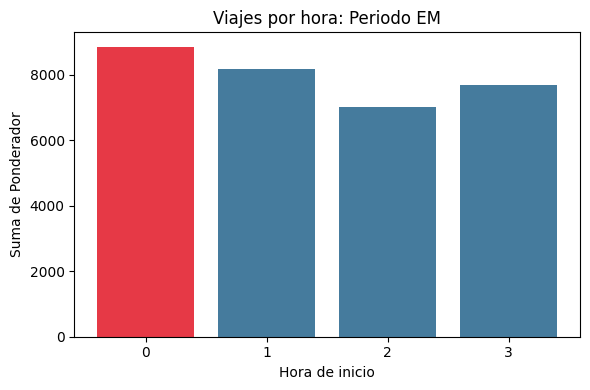

In [33]:
colores = ["#E63946" if bar == em_peak else "#457B9D" for bar in suma_por_hora_em.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_em.index.astype(str), suma_por_hora_em.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo EM")
plt.tight_layout()
plt.show()

In [34]:
em_peak_factor = em_peak_value / em_total
print("peak factor de EM: ", em_peak_factor)

peak factor de EM:  0.27890191628845185


## Análisis de AP: AM Peak

In [35]:
ap = matriz_global_priv[matriz_global_priv["Periodo"] == "AP"]

suma_por_hora_ap = ap.groupby("Hora_inicio")["Ponderador"].sum()
ap_total = suma_por_hora_ap.sum()
print("Total de viajes en AP:", ap_total)
print(suma_por_hora_ap)
ap_peak = suma_por_hora_ap.idxmax()
ap_peak_value = suma_por_hora_ap.max()

print("Hora pico: ", ap_peak,", con ", ap_peak_value, "  viajes.")

Total de viajes en AP: 992363
Hora_inicio
4     23188
5     98844
6    226980
7    364851
8    278500
Name: Ponderador, dtype: int64
Hora pico:  7 , con  364851   viajes.


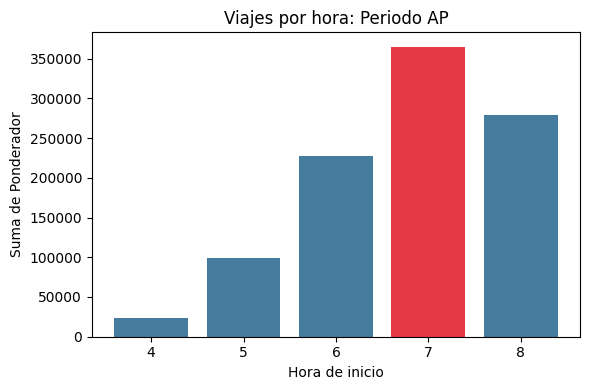

In [36]:
colores = ["#E63946" if bar == ap_peak else "#457B9D" for bar in suma_por_hora_ap.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_ap.index.astype(str), suma_por_hora_ap.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo AP")
plt.tight_layout()
plt.show()

In [37]:
ap_peak_factor = ap_peak_value / ap_total
print("peak factor de AP: ", ap_peak_factor)

peak factor de AP:  0.36765881033452474


## Análisis de LM: Late Morning

In [38]:
lm = matriz_global_priv[matriz_global_priv["Periodo"] == "LM"]

suma_por_hora_lm = lm.groupby("Hora_inicio")["Ponderador"].sum()
lm_total = suma_por_hora_lm.sum()
print("Total de viajes en LM:", lm_total)
print(suma_por_hora_lm)
lm_peak = suma_por_hora_lm.idxmax()
lm_peak_value = suma_por_hora_lm.max()

print("Hora pico: ", lm_peak,", con ", lm_peak_value, "  viajes.")

Total de viajes en LM: 505774
Hora_inicio
9     173472
10    161136
11    171166
Name: Ponderador, dtype: int64
Hora pico:  9 , con  173472   viajes.


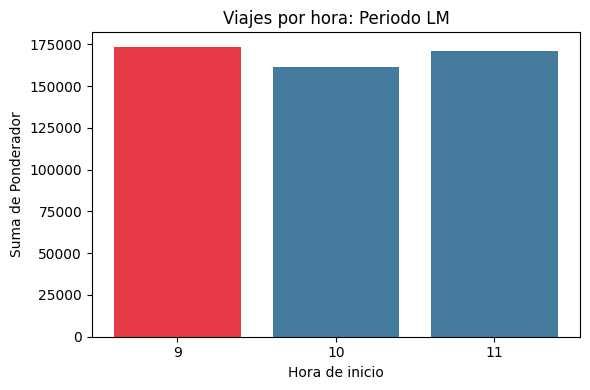

In [39]:
colores = ["#E63946" if bar == lm_peak else "#457B9D" for bar in suma_por_hora_lm.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_lm.index.astype(str), suma_por_hora_lm.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo LM")
plt.tight_layout()
plt.show()

In [40]:
lm_peak_factor = lm_peak_value / lm_total
print("peak factor de LM: ", lm_peak_factor)

peak factor de LM:  0.3429832296638419


## Análisis de EA: Early Afternoon

In [41]:
ea = matriz_global_priv[matriz_global_priv["Periodo"] == "EA"]

suma_por_hora_ea = ea.groupby("Hora_inicio")["Ponderador"].sum()
ea_total = suma_por_hora_ea.sum()
print("Total de viajes en EA:", ea_total)
print(suma_por_hora_ea)
ea_peak = suma_por_hora_ea.idxmax()
ea_peak_value = suma_por_hora_ea.max()

print("Hora pico: ", ea_peak,", con ", ea_peak_value, "  viajes.")

Total de viajes en EA: 1535297
Hora_inicio
12    261890
13    297556
14    265563
15    244074
16    232731
17    233483
Name: Ponderador, dtype: int64
Hora pico:  13 , con  297556   viajes.


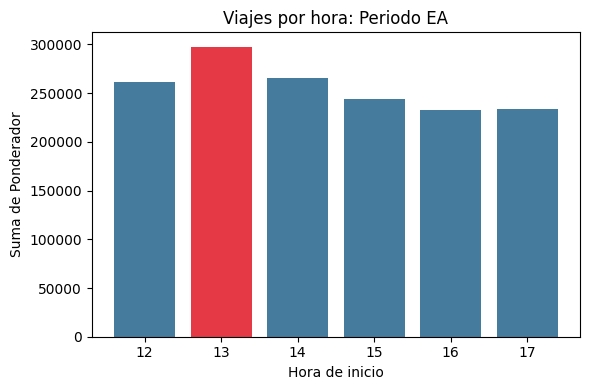

In [42]:
colores = ["#E63946" if bar == ea_peak else "#457B9D" for bar in suma_por_hora_ea.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_ea.index.astype(str), suma_por_hora_ea.values, color=colores)

plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo EA")
plt.tight_layout()
plt.show()

In [43]:
ea_peak_factor = ea_peak_value / ea_total
print("peak factor de EA: ", ea_peak_factor)

peak factor de EA:  0.19381005759797615


## Análisis de PP: PM Peak

In [44]:
pp = matriz_global_priv[matriz_global_priv["Periodo"] == "PP"]

suma_por_hora_pp = pp.groupby("Hora_inicio")["Ponderador"].sum()
pp_total = suma_por_hora_pp.sum()
print("Total de viajes en PP:", pp_total)
print(suma_por_hora_pp)
pp_peak = suma_por_hora_pp.idxmax()
pp_peak_value = suma_por_hora_pp.max()

print("Hora pico: ", pp_peak,", con ", pp_peak_value, "  viajes.")

Total de viajes en PP: 671941
Hora_inicio
18    298480
19    206501
20    166960
Name: Ponderador, dtype: int64
Hora pico:  18 , con  298480   viajes.


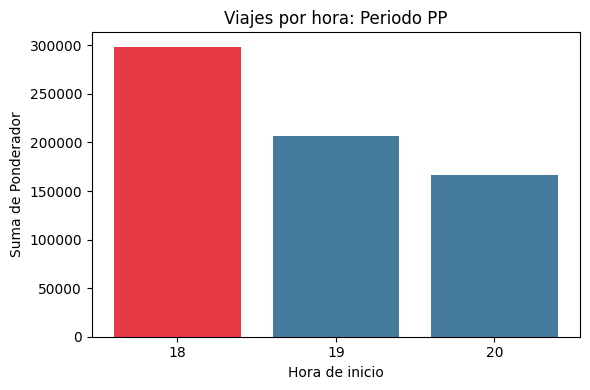

In [45]:
colores = ["#E63946" if bar == pp_peak else "#457B9D" for bar in suma_por_hora_pp.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_pp.index.astype(str), suma_por_hora_pp.values, color=colores)

plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo PP")
plt.tight_layout()
plt.show()

In [46]:
pp_peak_factor = pp_peak_value / pp_total
print("peak factor de PP: ", pp_peak_factor)

peak factor de PP:  0.444205666866585


## Análisis de LN: Late Night

In [47]:
ln = matriz_global_priv[matriz_global_priv["Periodo"] == "LN"]

suma_por_hora_ln = ln.groupby("Hora_inicio")["Ponderador"].sum()
ln_total = suma_por_hora_ln.sum()
print("Total de viajes en LN:", ln_total)
print(suma_por_hora_ln)
ln_peak = suma_por_hora_ln.idxmax()
ln_peak_value = suma_por_hora_ln.max()

print("Hora pico: ", ln_peak,", con ", ln_peak_value, "  viajes.")

Total de viajes en LN: 200175
Hora_inicio
21    91355
22    63630
23    45190
Name: Ponderador, dtype: int64
Hora pico:  21 , con  91355   viajes.


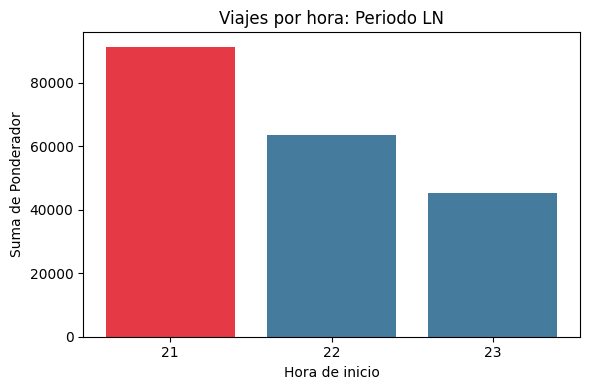

In [48]:
colores = ["#E63946" if bar == ln_peak else "#457B9D" for bar in suma_por_hora_ln.index]

plt.figure(figsize=(6, 4))
plt.bar(suma_por_hora_ln.index.astype(str), suma_por_hora_ln.values, color=colores)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora: Periodo LN")
plt.tight_layout()
plt.show()

In [49]:
ln_peak_factor = ln_peak_value / ln_total
print("peak factor de LN: ", ln_peak_factor)

peak factor de LN:  0.45637567128762335


# Análisis global

In [50]:
resumen = pd.DataFrame({
    "Periodo": ["EM", "AP", "LM", "EA", "PP", "LN"],
    "Hora pico": [em_peak, ap_peak, lm_peak, ea_peak, pp_peak, ln_peak],
    "Número de viajes en hora pico": [em_peak_value, ap_peak_value, lm_peak_value, ea_peak_value, pp_peak_value, ln_peak_value],
    "Total de viajes por periodo": [em_total, ap_total, lm_total, ea_total, pp_total, ln_total],
    "Peak factor por periodo": [em_peak_factor, ap_peak_factor, lm_peak_factor, ea_peak_factor, pp_peak_factor, ln_peak_factor],
})

resumen

,Periodo,Hora pico,Número de viajes en hora pico,Total de viajes por periodo,Peak factor por periodo
0,EM,0,8849,31728,0.278902
1,AP,7,364851,992363,0.367659
2,LM,9,173472,505774,0.342983
3,EA,13,297556,1535297,0.193810
4,PP,18,298480,671941,0.444206
5,LN,21,91355,200175,0.456376


In [51]:
suma_por_hora_dia = matriz_global_priv.groupby("Hora_inicio")["Ponderador"].sum()
print("Total de viajes: ",suma_por_hora_dia.sum())

Total de viajes:  3937278


In [52]:
def formato_corto(valor):
    if valor >= 1_000_000:
        return f"{valor/1_000_000:.2f}M"
    elif valor >= 1_000:
        return f"{valor/1_000:.0f}K"
    else:
        return f"{valor:.0f}"

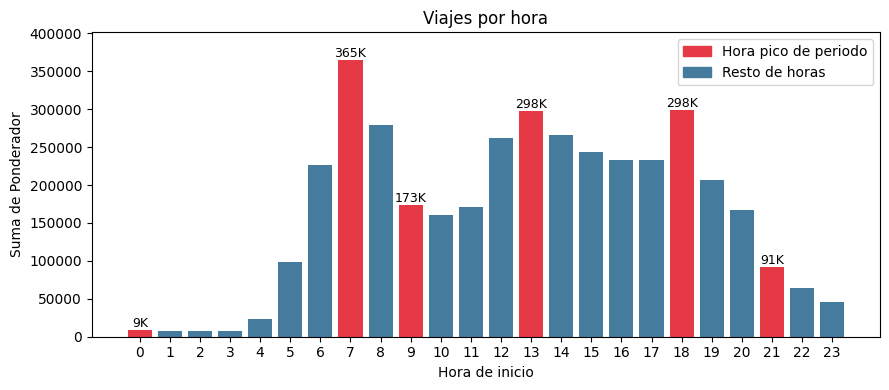

In [53]:
horas_pico = {em_peak, ap_peak, lm_peak, ea_peak, pp_peak, ln_peak}

colores = ["#E63946" if h in horas_pico else "#457B9D" for h in suma_por_hora_dia.index]

plt.figure(figsize=(9, 4))
barras = plt.bar(suma_por_hora_dia.index.astype(str), suma_por_hora_dia.values, color=colores)
for barra, hora, valor in zip(barras, suma_por_hora_dia.index, suma_por_hora_dia.values):
    if hora in horas_pico:
        plt.text(barra.get_x() + barra.get_width()/2, valor, formato_corto(valor),
                 ha="center", va="bottom", fontsize=9)
plt.xlabel("Hora de inicio")
plt.ylabel("Suma de Ponderador")
plt.title("Viajes por hora")
plt.legend(handles=[Patch(color="#E63946", label="Hora pico de periodo"),
                     Patch(color="#457B9D", label="Resto de horas")])

plt.ylim(0, suma_por_hora_dia.max() * 1.10)
plt.tight_layout()
plt.show()

Se distingue como a las 7 AM y 6 PM se forman los picos más altos, pudiera asociarse a las horas de salidad de casa y regreso a casa, relacionado con las horas entrada y salida de la mayoría de los trabajos.